In [1]:
pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


In [2]:
import joblib
import shap
import pandas as pd
import matplotlib.pyplot as plt

shap.initjs()

In [3]:
pipeline = joblib.load("../models/best_credit_risk_pipeline.pkl")

In [4]:
df = pd.read_csv("../data/processed/credit_risk_analytics.csv")

X = df.drop(columns=["customer_id", "default_next_month"])

In [5]:
preprocessor = pipeline.named_steps["preprocessor"]

model = pipeline.named_steps["classifier"]

In [6]:
X_processed = preprocessor.transform(X)

In [7]:
feature_names = preprocessor.get_feature_names_out()

In [8]:
explainer = shap.TreeExplainer(model)

In [9]:
shap_values = explainer.shap_values(X_processed)

In [10]:
shap_values = explainer.shap_values(X_processed)

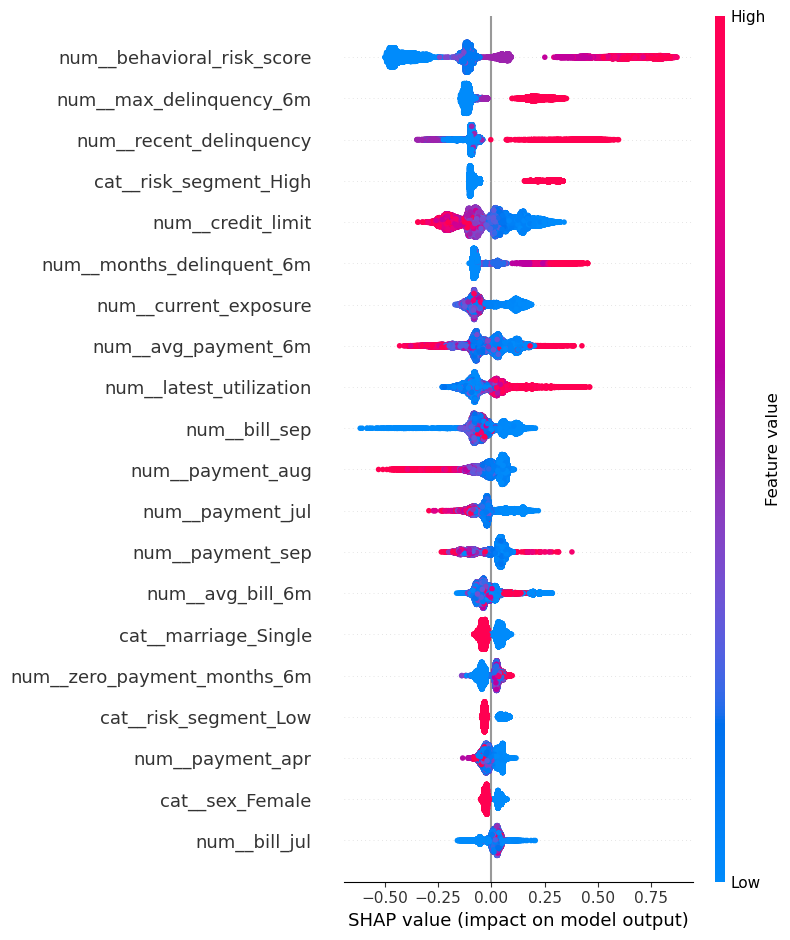

In [11]:
shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=feature_names
)

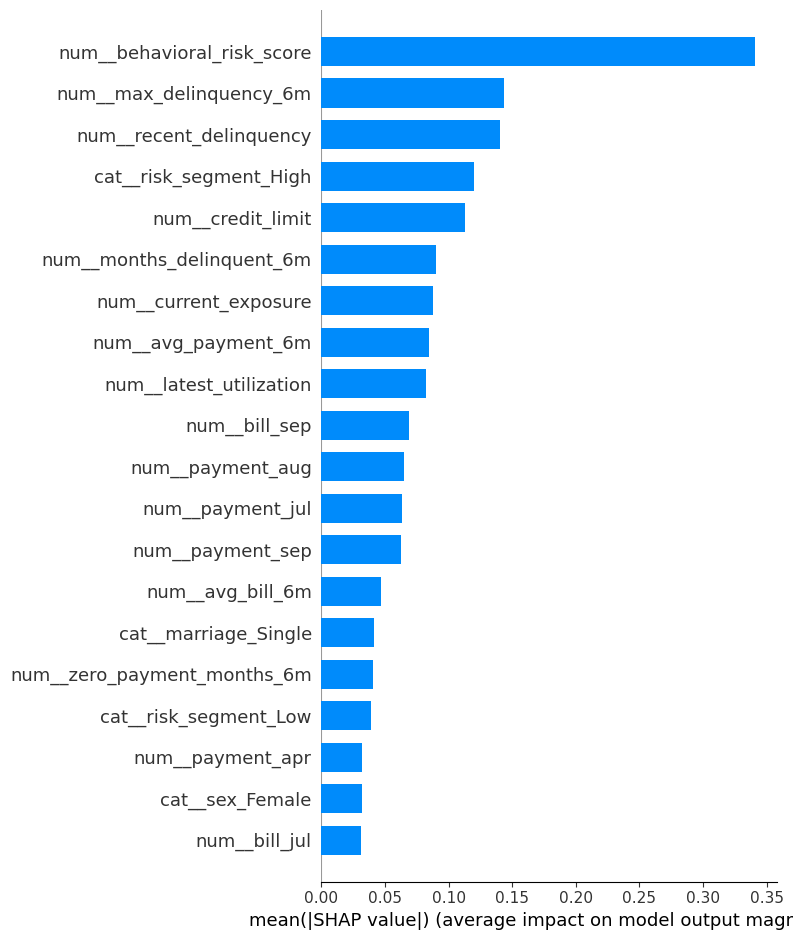

In [12]:
shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=feature_names,
    plot_type="bar"
)

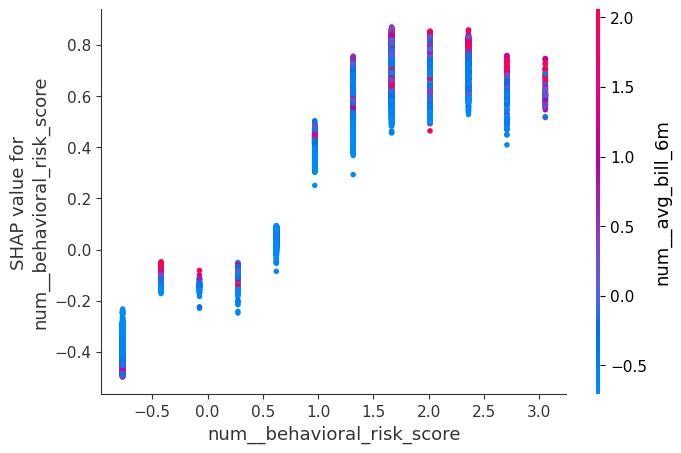

In [22]:
shap.dependence_plot(
    "num__behavioral_risk_score",
    shap_values,
    X_processed,
    feature_names=feature_names
)

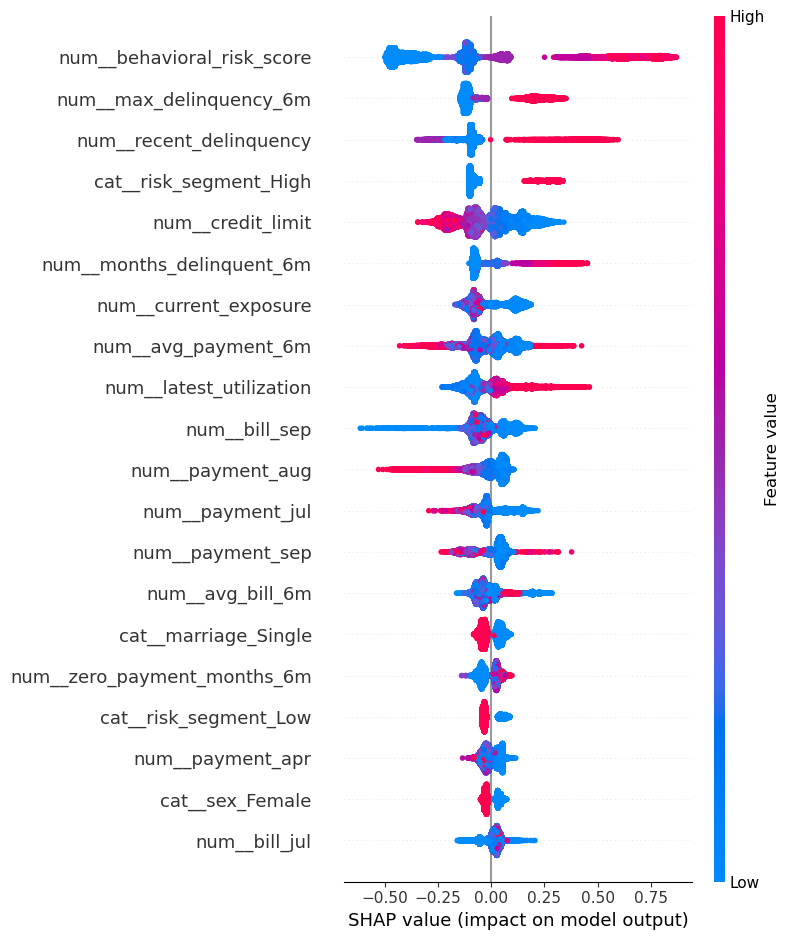

In [14]:
plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../Screenshots/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

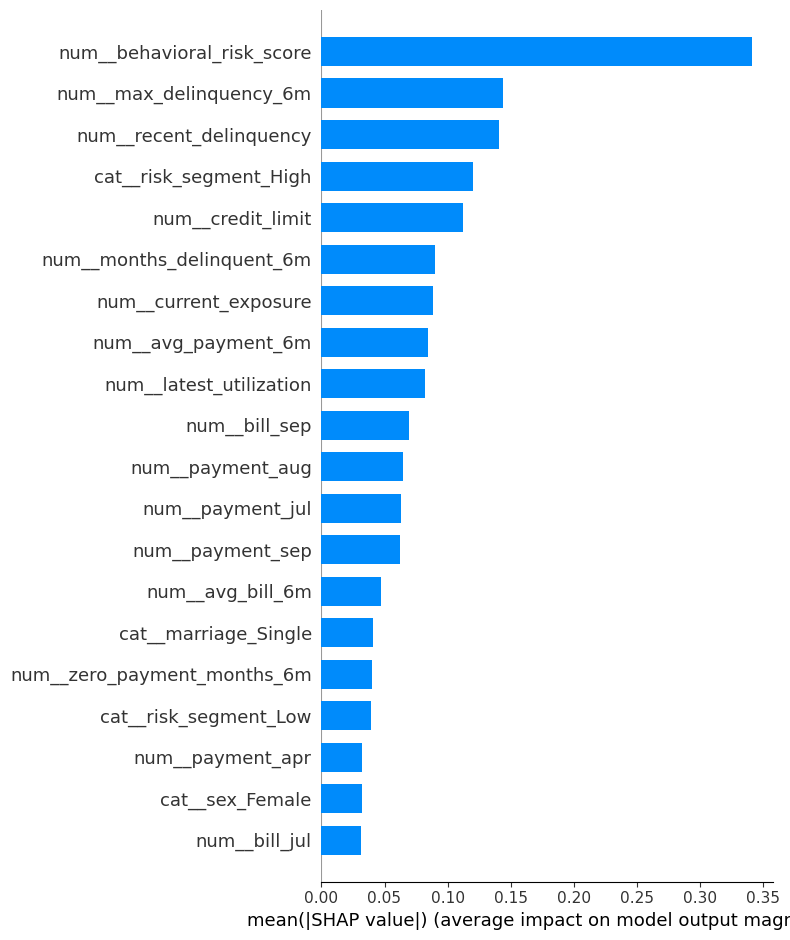

In [15]:
plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    "../Screenshots/shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
import numpy as np
importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_SHAP": np.abs(shap_values).mean(axis=0)
})

importance = importance.sort_values(
    by="Mean_SHAP",
    ascending=False
)

importance.head(15)

,Feature,Mean_SHAP
23,num__behavioral_risk_score,0.341157
19,num__max_delinquency_6m,0.143861
20,num__recent_delinquency,0.140576
50,cat__risk_segment_High,0.120007
0,num__credit_limit,0.112489
18,num__months_delinquent_6m,0.090219
14,num__current_exposure,0.088044
17,num__avg_payment_6m,0.084269
15,num__latest_utilization,0.082434
2,num__bill_sep,0.069030


In [20]:
importance.to_csv(
    "../results/shap_feature_importance.csv",
    index=False
)

In [21]:
summary = {
    "Final Model": "Optimized XGBoost",
    "Explainability Method": "SHAP",
    "Top Feature": importance.iloc[0]["Feature"],
    "Number of Features": len(feature_names)
}

pd.DataFrame(summary.items(),
             columns=["Property","Value"]).to_csv(
    "../results/model_explainability_summary.csv",
    index=False
)